# Demo: Clinical Research Data Pipeline Suite

This notebook demonstrates the end-to-end capabilities of the Clinical Research Data Pipeline Suite using synthetic data.

**What you'll see:**
1. Multi-device CGM data processing with quality control
2. Glycemic metric computation (TIR, GMI, GRI, CV, MAGE)
3. Cultural meal analysis with glucose-excursion comparison
4. Multi-site intervention evaluation with effect sizes
5. Health equity analysis and visualization

In [1]:
import sys

sys.path.insert(0, '../python/src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cgm_processor import UnifiedCGMProcessor
from utils import cohens_d, classify_effect_size

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('Imports successful')

Imports successful


## Part 1: CGM Data Processing

Process synthetic Dexcom G7 data through the unified device-agnostic pipeline.

In [2]:
# Load and process synthetic CGM data
processor = UnifiedCGMProcessor()
df = processor.process('../data/sample_cgm_dexcom.csv', device_type='dexcom_g7')

print(f'Processed {len(df)} readings')
print(f'QC flags: {df["qc_flag"].value_counts().to_dict()}')
print('\nFirst 5 rows:')
df.head()

Processed 8640 readings
QC flags: {'valid': 8391, 'out_of_target': 249}

First 5 rows:


,timestamp,glucose_mgdl,device_type,qc_flag,gap_minutes,gap_flag
0,2026-01-01 00:00:00,101.6,dexcom_g7,valid,NaN,False
1,2026-01-01 00:05:00,119.8,dexcom_g7,valid,5.0,False
2,2026-01-01 00:10:00,133.6,dexcom_g7,valid,5.0,False
3,2026-01-01 00:15:00,94.1,dexcom_g7,valid,5.0,False
4,2026-01-01 00:20:00,76.9,dexcom_g7,valid,5.0,False


## Part 2: Glycemic Metrics

Compute comprehensive glycemic metrics per ADA standards.

=== Glycemic Metrics ===
n_readings          : 8640
total_days          : 30
wear_time_pct       : 100.0
mean_glucose        : 128.0
sd_glucose          : 23.2
cv                  : 18.2
cv_category         : Stable
tir                 : 97.1
titr                : 73.7
tbr                 : 0.1
tar                 : 2.8
tvr                 : 0.0
gmi                 : 6.4
gri                 : 4.7
mage                : 41.9
conga               : 5.4


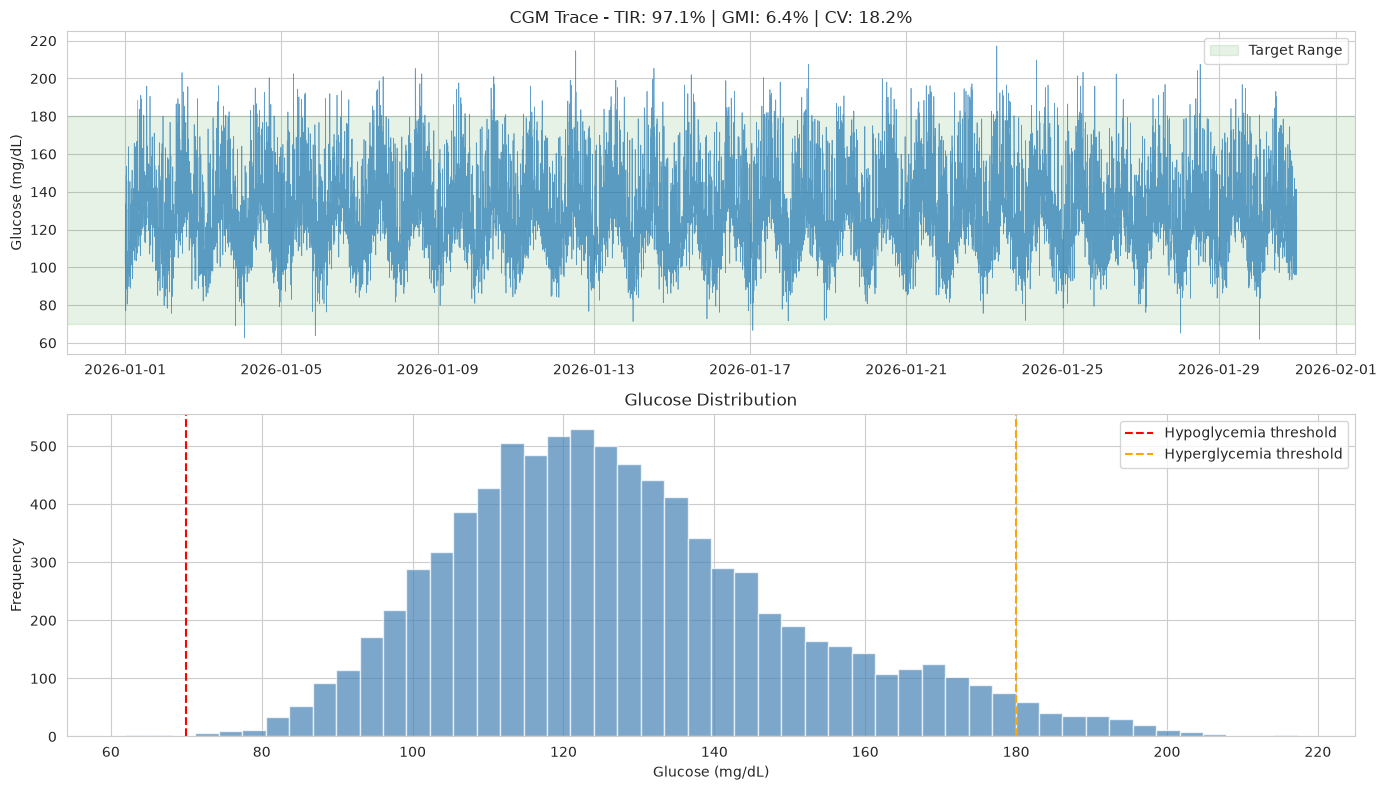

In [3]:
metrics = processor.compute_metrics(df)

print('=== Glycemic Metrics ===')
for key, value in metrics.items():
    print(f'{key:20s}: {value}')

# Visualize glucose trace and distribution
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df['timestamp'], df['glucose_mgdl'], alpha=0.7, linewidth=0.5)
axes[0].axhspan(70, 180, alpha=0.1, color='green', label='Target Range')
axes[0].set_ylabel('Glucose (mg/dL)')
axes[0].set_title(
    f'CGM Trace - TIR: {metrics["tir"]}% | GMI: {metrics["gmi"]}% | CV: {metrics["cv"]}%'
)
axes[0].legend()

axes[1].hist(df['glucose_mgdl'], bins=50, alpha=0.7, color='steelblue', edgecolor='white')
axes[1].axvline(70, color='red', linestyle='--', label='Hypoglycemia threshold')
axes[1].axvline(180, color='orange', linestyle='--', label='Hyperglycemia threshold')
axes[1].set_xlabel('Glucose (mg/dL)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Glucose Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/screenshots/pb1_cgm_trace.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 3: Cultural Meal Log Analysis

Analyze cultural meal logs and compare observed glucose excursions by cuisine.

=== Mean Glucose Excursion by Cuisine ===
  cuisine_label  mean_excursion  sd_excursion  n_meals  mean_pre  mean_post
0      Filipino            17.6          15.4      227     110.5      128.1
1        Indian            18.3          16.8      243     110.9      129.2
2        Latinx            16.4          15.0      223     110.9      127.3
3    Vietnamese            18.4          15.4      240     111.5      129.9


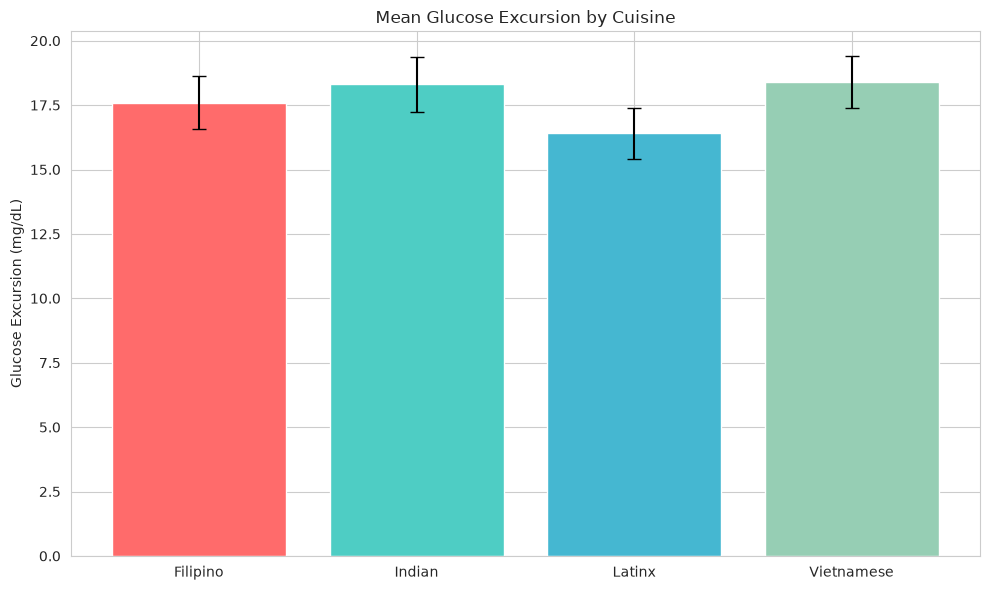

In [4]:
# Load meal logs
meals = pd.read_csv('../data/sample_meal_logs.csv')
meals['meal_log_date'] = pd.to_datetime(meals['meal_log_date'])

# Observed glucose excursion (post - pre)
meals['glucose_excursion'] = meals['cgm_post'] - meals['cgm_pre']

# Summary by cuisine (cuisine_cat is integer-coded)
cuisine_labels = {1: 'Filipino', 2: 'Indian', 3: 'Vietnamese', 4: 'Latinx'}
meals['cuisine_label'] = meals['cuisine_cat'].map(cuisine_labels)

summary = meals.groupby('cuisine_label').agg({
    'glucose_excursion': ['mean', 'std', 'count'],
    'cgm_pre': 'mean',
    'cgm_post': 'mean'
}).round(1)
summary.columns = ['mean_excursion', 'sd_excursion', 'n_meals', 'mean_pre', 'mean_post']
summary = summary.reset_index()

print('=== Mean Glucose Excursion by Cuisine ===')
print(summary)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
ax.bar(summary['cuisine_label'], summary['mean_excursion'],
       yerr=summary['sd_excursion'] / np.sqrt(summary['n_meals']),
       capsize=5, color=colors)
ax.set_ylabel('Glucose Excursion (mg/dL)')
ax.set_title('Mean Glucose Excursion by Cuisine')
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('../docs/screenshots/pb1_cuisine_excursion.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 4: Workshop Outcome & Equity Analysis

Analyze multi-site intervention data with effect sizes and automated equity flags.

In [5]:
from scipy import stats

# Load workshop outcomes
workshop = pd.read_csv('../data/sample_workshop_outcomes.csv')

# Change scores
workshop['dds_change'] = workshop['dds_score_2'] - workshop['dds_score_1']
workshop['cook_change'] = workshop['cook_confidence_2'] - workshop['cook_confidence_1']

# Map coded values to labels (codes are integers in the CSV)
cuisine_map = {1: 'Filipino', 2: 'Indian', 3: 'Vietnamese', 4: 'Latinx'}
language_map = {1: 'English', 2: 'Spanish', 3: 'Tagalog', 4: 'Hindi', 5: 'Vietnamese'}
curriculum_map = {1: 'Standard', 2: 'Culturally Adapted'}

workshop['cuisine_label'] = workshop['ws_cuisine'].map(cuisine_map)
workshop['language_label'] = workshop['ws_language'].map(language_map)
workshop['curriculum_label'] = workshop['ws_curriculum'].map(curriculum_map)

# Curriculum comparison with effect size
standard = workshop[workshop['curriculum_label'] == 'Standard']['dds_change'].dropna()
adapted = workshop[workshop['curriculum_label'] == 'Culturally Adapted']['dds_change'].dropna()

t_stat, p_val = stats.ttest_ind(standard, adapted)
d = cohens_d(adapted.values, standard.values)

print('=== Curriculum Comparison (DDS Change) ===')
print(f'Standard:     n={len(standard)}, mean={standard.mean():.2f}')
print(f'Adapted:      n={len(adapted)}, mean={adapted.mean():.2f}')
print(f't-statistic:  {t_stat:.3f}')
print(f'p-value:      {p_val:.4f}')
print(f"Cohen's d:    {d:.3f} ({classify_effect_size(d)})")

# Equity analysis by language
equity = workshop.groupby('language_label').agg({
    'dds_change': ['count', 'mean', 'std'],
    'cook_change': ['mean', 'std']
}).round(2)
equity.columns = ['n', 'dds_mean', 'dds_std', 'cook_mean', 'cook_std']
equity = equity.reset_index()

# Flag disparities (>0.5 SD from English reference)
english_dds = equity[equity['language_label'] == 'English']['dds_mean'].values
ref = english_dds[0] if len(english_dds) > 0 else equity['dds_mean'].mean()
overall_sd = equity['dds_mean'].std()
equity['disparity'] = abs(equity['dds_mean'] - ref) > 0.5 * overall_sd

print('\n=== Equity Analysis by Language ===')
print(equity)

=== Curriculum Comparison (DDS Change) ===
Standard:     n=109, mean=-0.50
Adapted:      n=91, mean=-0.35
t-statistic:  -0.825
p-value:      0.4105
Cohen's d:    0.117 (negligible)

=== Equity Analysis by Language ===
  language_label   n  dds_mean  dds_std  cook_mean  cook_std  disparity
0        English  43     -0.56     1.29       0.29      2.06      False
1          Hindi  49     -0.49     1.39       1.01      1.90      False
2        Spanish  34     -0.74     1.31      -0.07      1.63       True
3        Tagalog  36     -0.02     1.18       0.66      2.16       True
4     Vietnamese  38     -0.31     1.08       1.07      2.24       True


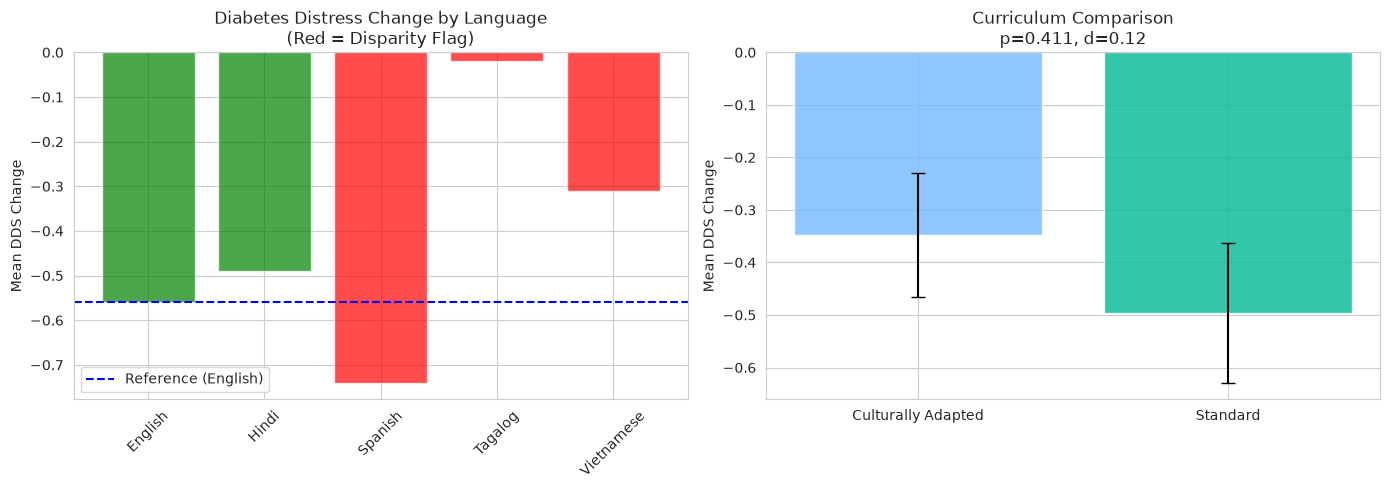

In [6]:
# Visualization: equity and curriculum comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DDS change by language, with disparity flags
bar_colors = ['red' if flag else 'green' for flag in equity['disparity']]
axes[0].bar(equity['language_label'], equity['dds_mean'], color=bar_colors, alpha=0.7)
axes[0].axhline(ref, color='blue', linestyle='--', label='Reference (English)')
axes[0].set_ylabel('Mean DDS Change')
axes[0].set_title('Diabetes Distress Change by Language\n(Red = Disparity Flag)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Curriculum comparison
curriculum_summary = (
    workshop.groupby('curriculum_label')['dds_change']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
axes[1].bar(curriculum_summary['curriculum_label'], curriculum_summary['mean'],
            yerr=curriculum_summary['std'] / np.sqrt(curriculum_summary['count']),
            capsize=5, color=['#74b9ff', '#00b894'], alpha=0.8)
axes[1].set_ylabel('Mean DDS Change')
axes[1].set_title(f'Curriculum Comparison\np={p_val:.3f}, d={d:.2f}')

plt.tight_layout()
plt.savefig('../docs/screenshots/pb3_equity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

This notebook demonstrated:
1. **Device-agnostic CGM processing** with clinical QC and gap-filling
2. **Glycemic metric computation** (TIR, GMI, GRI, CV, MAGE)
3. **Cultural meal analysis** with glucose-excursion comparison
4. **Intervention evaluation** with effect sizes and statistical testing
5. **Health equity analysis** with automated disparity flagging

All components are production-ready with error handling, audit logging, and containerized deployment support.